<a href="https://colab.research.google.com/github/DataMind-Society/Weather-Classification-Project/blob/main/WeatherClass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Type Classification

This project focuses on building  machine learning models to predict weather conditions based on environmental and atmospheric data.

The dataset includes features such as temperature, humidity, wind speed, precipitation percentage, cloud cover, atmospheric pressure, UV index, season, visibility, and location. The target variable is the weather type, which can be categories such as rainy, sunny, cloudy, or snowy.

Weather Type Classification Dataset by Nikhil Narayan, available on Kaggle.
Source: https://www.kaggle.com/datasets/nikhil7280/weather-type-classification/data

Import our libraries (and sublibraries)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

## 1. Load your data after uploading it in the colab files using the file button and pressing the upload button and picking you dataset

In [ ]:
df = pd.read_csv("weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


This dataset contains multiple weather-related variables like temperature, humidity, wind speed, and more.

## 2. Let us understand our data

In [ ]:
df.info() #1st table
df.describe() #2nd table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


## Dataset Notes & Outliers

This dataset is **synthetic** and designed for machine learning practice.

This dataset contains **Outliers**: data points that differ significantly from other data in a dataset. They usually arise from different errors in data collection or ...

**NOTE THAT OUTLIERS DOES NOT ALWAYS MEAN UNPHYSICAL VALUES.**

# **We also have categorical data (words) which we will deal with later.**

We may use **box plots** to visualize outliers

## Temperature
- Contains extreme and unrealistic values (e.g. 109°C)   
- Included to test model robustness to extreme data

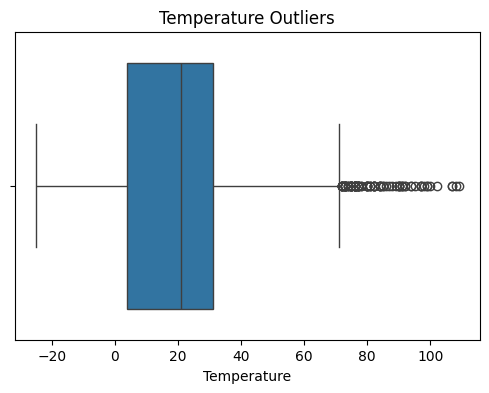

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Temperature"])
plt.title("Temperature Outliers")
plt.show()

##  Humidity
- Some values exceed 100%   
- Represents sensor noise or data recording errors

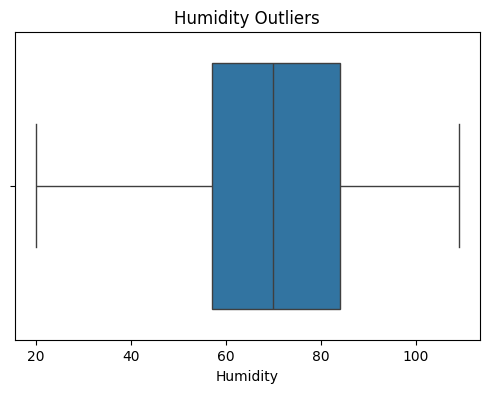

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Humidity"])
plt.title("Humidity Outliers")
plt.show()

The 109 % value is still close to the second largest value BUT HUMIDITY CANNOT BE MORE THAN 100 %

##  Wind Speed
- Includes unusually high values (up to 48.5 km/h)  
- Some values may be outliers compared to normal weather patterns

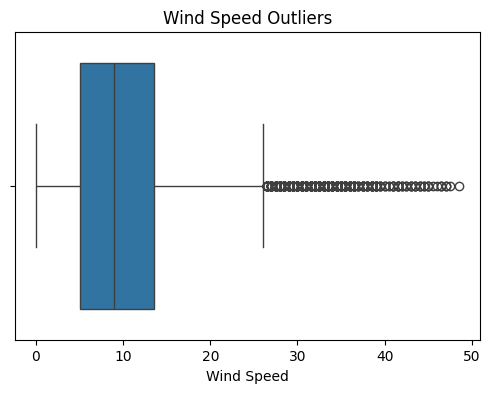

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Wind Speed"])
plt.title("Wind Speed Outliers")
plt.show()

##  Precipitation (%)
- Contains values outside normal realistic percentage ranges like 109 %
- Added to simulate noisy real-world measurements

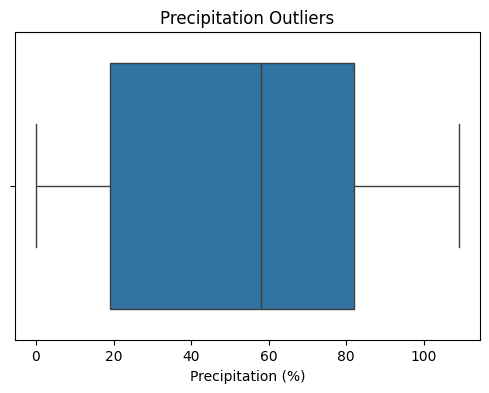

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Precipitation (%)"])
plt.title("Precipitation Outliers")
plt.show()

Again close values and cannot be more than 100%.

##  Atmospheric Pressure
- Very wide range (800 hPa to 1199 hPa)  
- Includes unrealistic extreme values  

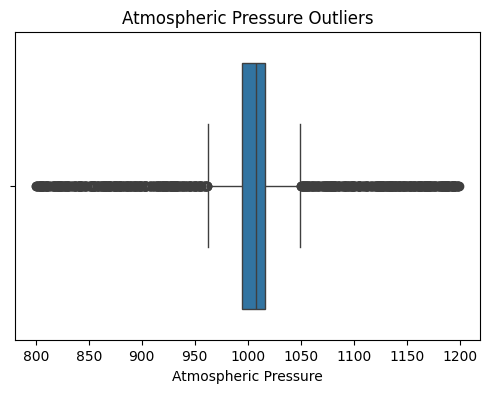

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Atmospheric Pressure"])
plt.title("Atmospheric Pressure Outliers")
plt.show()

## UV Index
- Some values exceed typical real-world maximum levels  

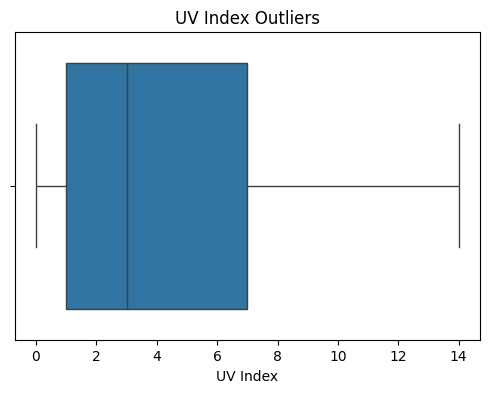

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["UV Index"])
plt.title("UV Index Outliers")
plt.show()

## 3. Check for empty values.

In [ ]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


Perfect we don't have missing data so we **DO NOT** HAVE TO REPLACE THE NULL VALUES

# Dealing with outliers and unphysical values

Small note: let us COPY the original dataframe (df) to a new dataframe which is df_cleaned.




In [ ]:
 #Make a copy to keep the original dataset
df_clean = df.copy()

# Temperature (reasonable Earth range)
df_clean["Temperature"] = df_clean["Temperature"].clip(-30, 50)

# Humidity (0–100%)
df_clean["Humidity"] = df_clean["Humidity"].clip(0, 100)

# Wind Speed
df_clean["Wind Speed"] = df_clean["Wind Speed"].clip(0, 60)

# Precipitation (0–100%)
df_clean["Precipitation (%)"] = df_clean["Precipitation (%)"].clip(0, 100)

# Atmospheric Pressure (850-1100)
df_clean["Atmospheric Pressure"] = df_clean["Atmospheric Pressure"].clip(850, 1100)

# UV Index (0–15 typical max range)
df_clean["UV Index"] = df_clean["UV Index"].clip(0, 15)

# Visibility (0–20 km)
df_clean["Visibility (km)"] = df_clean["Visibility (km)"].clip(0, 20)

Note: `clip()` in pandas is used to trim and restrict values at a specific lower and/or upper threshold.

In [ ]:
df_clean.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,18.705909,68.547879,9.832197,53.496212,1004.882025,4.005758,5.462917
std,16.292008,19.913514,6.908704,31.715382,31.150259,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,850.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,50.000000,100.000000,48.500000,100.000000,1100.000000,14.000000,20.000000


## Here is an example after fixing the temperature outliers/illogical values

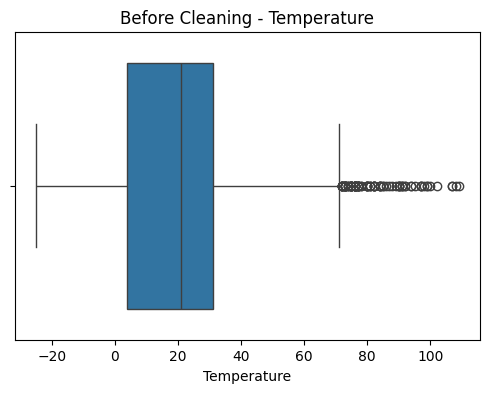

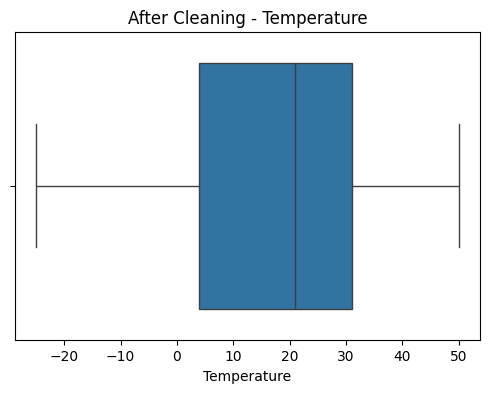

In [ ]:
#df

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Temperature"])
plt.title("Before Cleaning - Temperature")
plt.show()

#df_cleaned
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["Temperature"])
plt.title("After Cleaning - Temperature")
plt.show()

## 4. Dealing with non-numerical data



1.   Cloud Cover	 --> One-Hot Encoding
2.   Season	       --> One-Hot Encoding
3.   Location	    --> One-Hot Encoding
4.   Weather Type	--> Label Encoding

In [ ]:
df_clean.head(99)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
94,32.0,38,11.0,15.0,partly cloudy,850.00,9,Autumn,12.5,inland,Snowy
95,17.0,88,18.0,83.0,partly cloudy,1026.94,0,Spring,5.5,mountain,Sunny
96,23.0,88,11.5,65.0,overcast,1000.74,1,Winter,5.0,mountain,Rainy
97,28.0,35,9.5,0.0,partly cloudy,1023.62,9,Winter,10.0,coastal,Sunny


In [ ]:
# Let us copy again
df_model = df_clean.copy()


##  Train-Test Split

In this step, the dataset is divided into two parts: a **training set** and a **testing set**.

* The **training set** is used to train the machine learning model so it can learn patterns from the data.
* The **testing set** is used to evaluate the model’s performance on unseen data.

We use an **80/20 split**, meaning:

* 80% of the data is used for training
* 20% is used for testing

This helps ensure that the model is not just memorizing the data but can generalize to new inputs.

Additionally, we use **stratification** to maintain the same proportion of each weather type (e.g., rainy, sunny, cloudy, snowy) in both the training and testing sets. This is important for classification problems to avoid biased results.

The `random_state=42` parameter is used to ensure that the split is reproducible, meaning we get the same results each time we run the code.


 The `stratify` parameter ensures that the training and testing sets maintain the same proportion of class labels as the original dataset.

In [ ]:
#split the data:

from sklearn.model_selection import train_test_split #can be added at the top

X = df_model.drop("Weather Type", axis=1) #input
y = df_model["Weather Type"]              #output

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X: input data \
y: is the output data

## One-Hot Encoding

# **CAREFUL**


*   Use One-Hot Encoding for both X_train and X_test
*   Aligning columns after a train-test split and encoding is essential because categorical encoding (like One-Hot Encoding) can create different sets of columns for each dataset if they do not contain the exact same categories.



In [ ]:
X_train = pd.get_dummies(X_train, columns=["Cloud Cover", "Season", "Location"], dtype=int)

X_test = pd.get_dummies(X_test, columns=["Cloud Cover", "Season", "Location"], dtype=int)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


In [ ]:
df_model.head(99)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
94,32.0,38,11.0,15.0,partly cloudy,850.00,9,Autumn,12.5,inland,Snowy
95,17.0,88,18.0,83.0,partly cloudy,1026.94,0,Spring,5.5,mountain,Sunny
96,23.0,88,11.5,65.0,overcast,1000.74,1,Winter,5.0,mountain,Rainy
97,28.0,35,9.5,0.0,partly cloudy,1023.62,9,Winter,10.0,coastal,Sunny


## Label Encoding

NOTE: The **sklearn.preprocessing** (library: sklearn - sublibrary: preprocessing) contains the LabelEncoder() function that will help us for label encoding.

**Again, for each y.**

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

- 0: Cloudy
- 1: Rainy
- 2: Snowy
- 3: Sunny

In [ ]:
df_model.head(99)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
94,32.0,38,11.0,15.0,partly cloudy,850.00,9,Autumn,12.5,inland,Snowy
95,17.0,88,18.0,83.0,partly cloudy,1026.94,0,Spring,5.5,mountain,Sunny
96,23.0,88,11.5,65.0,overcast,1000.74,1,Winter,5.0,mountain,Rainy
97,28.0,35,9.5,0.0,partly cloudy,1023.62,9,Winter,10.0,coastal,Sunny


# Is Our Data Balanced?

# Using Pandas

In [ ]:
df_model["Weather Type"].value_counts()

,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


# Using NumPy for a more specific analysis

In [ ]:
print(np.bincount(y_train))
print(np.bincount(y_test))

[2640 2640 2640 2640]
[660 660 660 660]


Note that 2640 + 660 = 3300 (numbers of y_train + y_test)

# Percentage


In [ ]:
print(df_model["Weather Type"].value_counts(normalize=True)*100)

Weather Type
Rainy     25.0
Cloudy    25.0
Sunny     25.0
Snowy     25.0
Name: proportion, dtype: float64


# Visual Verification with Bar Plots

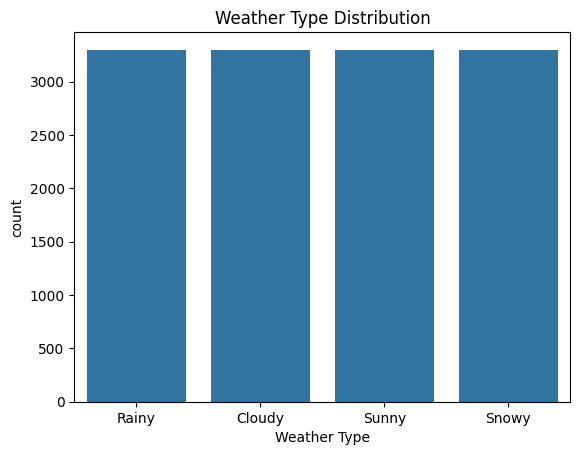

In [ ]:
sns.countplot(x=df_model["Weather Type"])
plt.title("Weather Type Distribution")
plt.show()

# More specifics

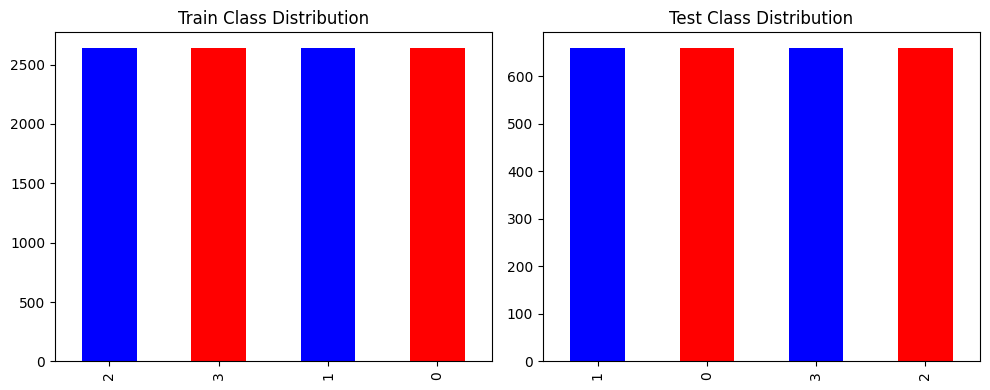

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
pd.Series(y_train).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Train Class Distribution')

plt.subplot(1, 2, 2)
pd.Series(y_test).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Test Class Distribution')

plt.tight_layout()
plt.show()

** Our data is perfectly split. In other cases they are always.**

# **Machine Learning Model Deployment**

We should import our models that we will use and some additional functions.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report , accuracy_score

# a) Decision Trees

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9053030303030303

# b) Random Forest

Think of it as many decision trees.
`n_estimators` is the number of decision trees.

In [ ]:
RF_model = RandomForestClassifier(n_estimators=100)
RF_model.fit(X_train , y_train)
RF_model.score(X_train , y_train)
RF_pred = RF_model.predict(X_test)
RF_acc = accuracy_score(y_test , RF_pred)



*  0: Cloudy
*  1: Rainy
*  2: Snowy
*  3: Sunny






In [ ]:
print(classification_report(y_test , RF_pred)) #of random forest

              precision    recall  f1-score   support

           0       0.87      0.92      0.90       660
           1       0.89      0.92      0.90       660
           2       0.96      0.91      0.93       660
           3       0.93      0.91      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640





1.   **Precision** tells us how accurate the model’s predictions are for each class.
2.  **Recall** tells us how well the model identifies all actual cases of a class.
3. **F1-score** is the predictive performance of the our model on our data.

Note: A **HIGH** F1 score indicates a robust model that avoids both overfitting and underfitting.

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$




4. **Macro average** treats all classes equally, calculating the unweighted mean of metrics (precision, recall, f1-score).
5. **Weighted average** calculates the mean of metrics weighted by each class's support

$$M_{Avg} = \frac{1}{K} \sum_{i=1}^{K} M_i$$
K: number of classes \
$M_i$: metric value for precision, or recall f1-score.


$$W_{avg} = \sum_{i=1}^{K} \frac{n_i}{N} \cdot M_i$$

K = number of classes \
$n_i$ = number of samples in class i \
N = total number of samples in the dataset \
$M_i$: metric value for precision, or recall f1-score.
